In [128]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

In [129]:
df = pd.read_excel("premiums.xlsx")
df.head(3)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164


In [130]:
df.shape

(50000, 13)

In [131]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [132]:
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


<h2 align="center" style="color:blue">Exploratory Data Analysis & Data Cleaning</h2>

#### Handling null and duplicated values

In [133]:
df.isnull().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [134]:
df["smoking_status"].unique()

array(['No Smoking', 'Regular', 'Occasional', nan, 'Smoking=0',
       'Does Not Smoke', 'Not Smoking'], dtype=object)

In [135]:
df["income_level"].dtype

dtype('O')

In [136]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values = np.nan, strategy="most_frequent")
df[["smoking_status"]] = imputer.fit_transform(df[["smoking_status"]])

In [137]:
df["smoking_status"].unique()

array(['No Smoking', 'Regular', 'Occasional', 'Smoking=0',
       'Does Not Smoke', 'Not Smoking'], dtype=object)

In [138]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values = np.nan, strategy="most_frequent")
df[["income_level"]] = imputer.fit_transform(df[["income_level"]])

In [139]:
df["income_level"].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [140]:
df.duplicated().sum()

np.int64(0)

In [141]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [142]:
df[df['number_of_dependants']<0]['number_of_dependants'].unique()

array([-3, -1])

In [143]:
df["number_of_dependants"] = abs(df["number_of_dependants"])

In [144]:
df["number_of_dependants"].describe()

count    50000.000000
mean         1.717520
std          1.492009
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

#### Handling outliers

#### 1. Numerical columns

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    50000 non-null  int64 
 1   gender                 50000 non-null  object
 2   region                 50000 non-null  object
 3   marital_status         50000 non-null  object
 4   number_of_dependants   50000 non-null  int64 
 5   bmi_category           50000 non-null  object
 6   smoking_status         50000 non-null  object
 7   employment_status      49998 non-null  object
 8   income_level           50000 non-null  object
 9   income_lakhs           50000 non-null  int64 
 10  medical_history        50000 non-null  object
 11  insurance_plan         50000 non-null  object
 12  annual_premium_amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


In [146]:
numerical_columns = df.select_dtypes(["int64"]).columns
numerical_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

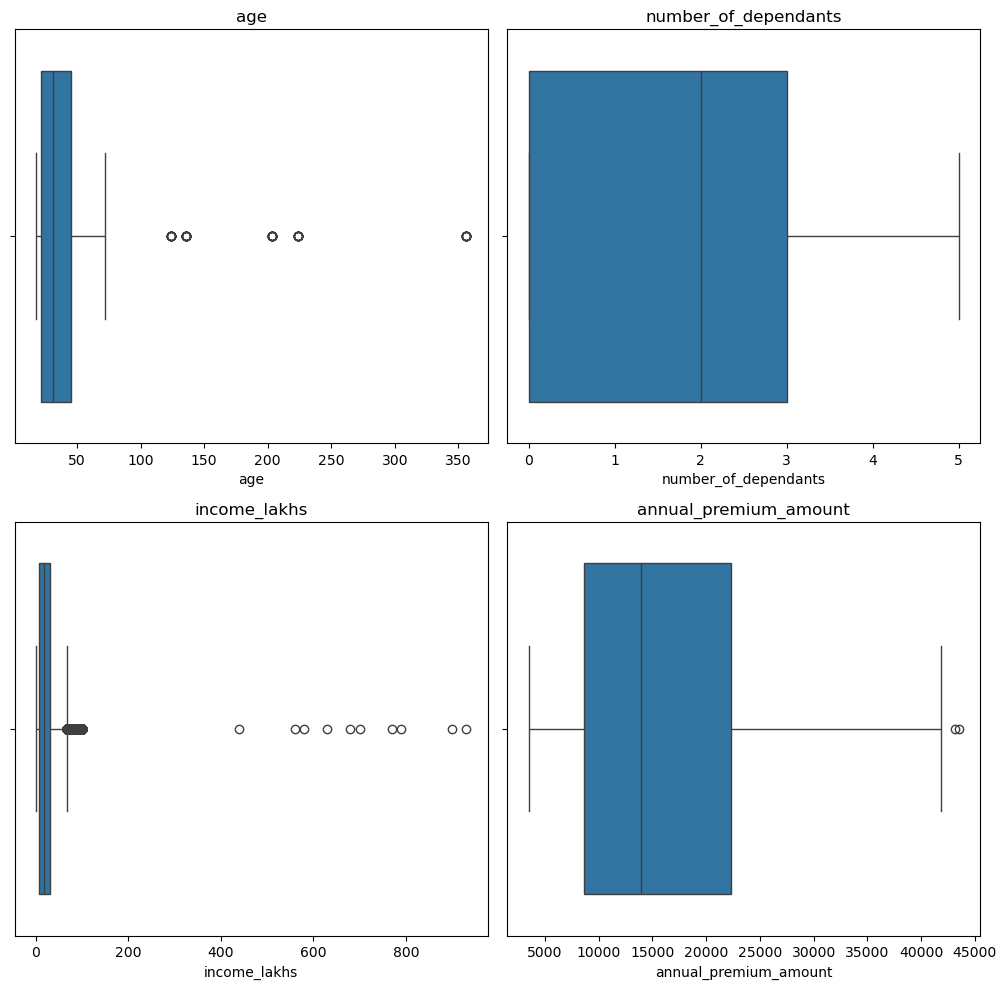

In [147]:
num_plots = len(numerical_columns)
num_cols = 2  
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))  # Adjust the figure size as needed
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col) 

for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

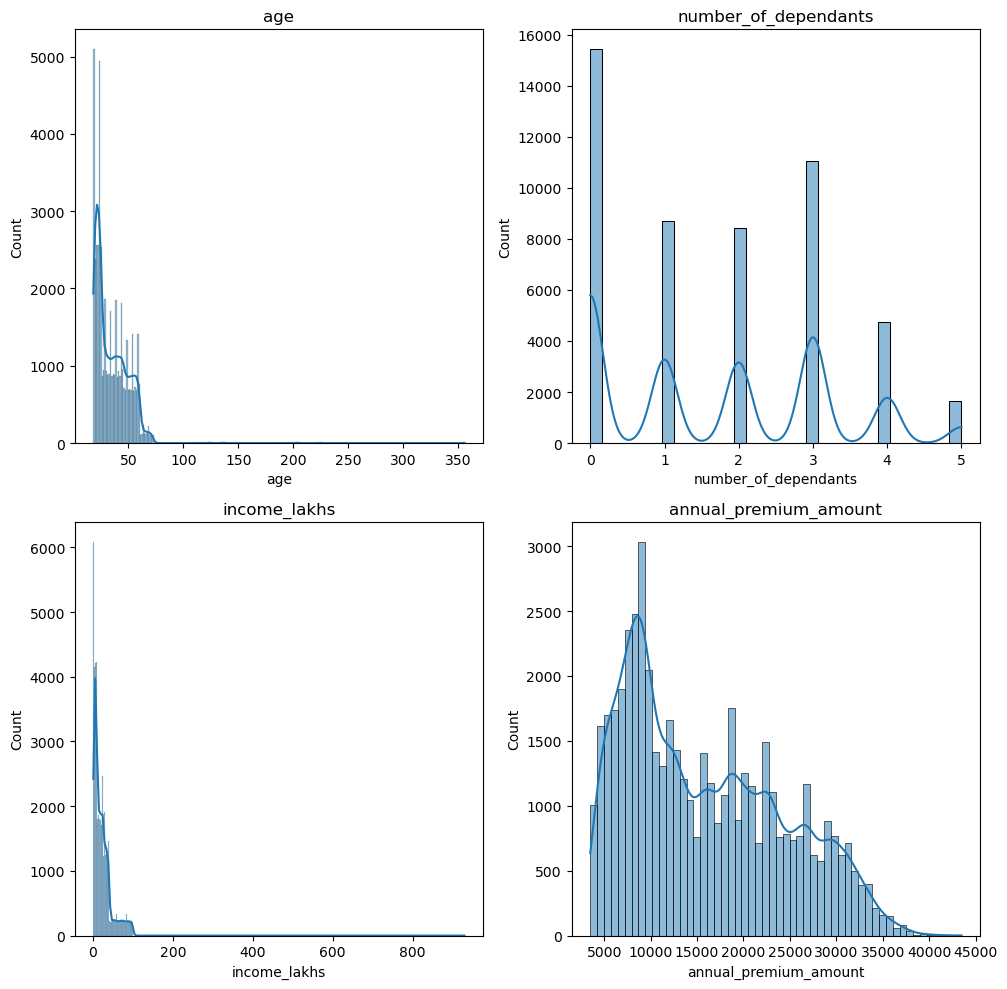

In [148]:
num_plots = len(numerical_columns)
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col) 

for j in range(i + 1, num_rows * num_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [149]:
df[df["age"]>100].shape

(58, 13)

In [150]:
df[df["age"]>100]["age"].unique()

array([224, 124, 136, 203, 356])

In [151]:
df1 = df[df["age"]<100]
df1["age"].describe()

count    49942.000000
mean        34.403648
std         13.682354
min         18.000000
25%         22.000000
50%         31.000000
75%         45.000000
max         72.000000
Name: age, dtype: float64

In [152]:
Q1 = df1["income_lakhs"].quantile(0.25)
Q3 = df1["income_lakhs"].quantile(0.75)
IQR = Q3-Q1
upper_range = Q3 + 1.5*IQR
lower_range = Q1 - 1.5*IQR
print(upper_range, lower_range)

67.0 -29.0


67 lakhs is a normal income in india, so we will drop the records where the values exceed the range of 0.999 quantile

In [153]:
df1[df1["income_lakhs"]> upper_range].shape

(3560, 13)

In [154]:
df1[df1["income_lakhs"]> upper_range]["income_lakhs"].unique()

array([ 77,  99,  97,  83,  70,  84,  71,  92,  93,  78,  68,  90,  88,
        86,  69,  95,  85,  81,  79,  80,  98,  89,  82, 100,  75,  94,
        74,  91,  87,  96,  73,  72, 560,  76, 440, 630, 900, 930, 580,
       700, 790, 770, 680])

In [155]:
threshold_quantile = df1["income_lakhs"].quantile(0.999)
threshold_quantile

np.float64(100.0)

In [156]:
df1[df1["income_lakhs"]>threshold_quantile]["income_lakhs"].shape

(10,)

In [157]:
df2 = df1[df1["income_lakhs"] <= threshold_quantile]
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [158]:
df2.shape

(49932, 13)

<Axes: xlabel='income_lakhs', ylabel='Count'>

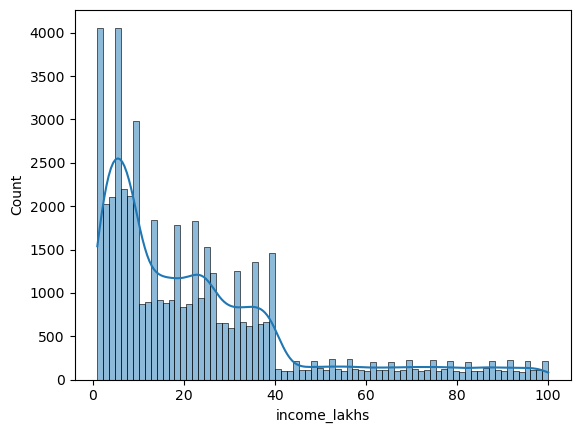

In [159]:
sns.histplot(data = df2, x ="income_lakhs", kde = True)

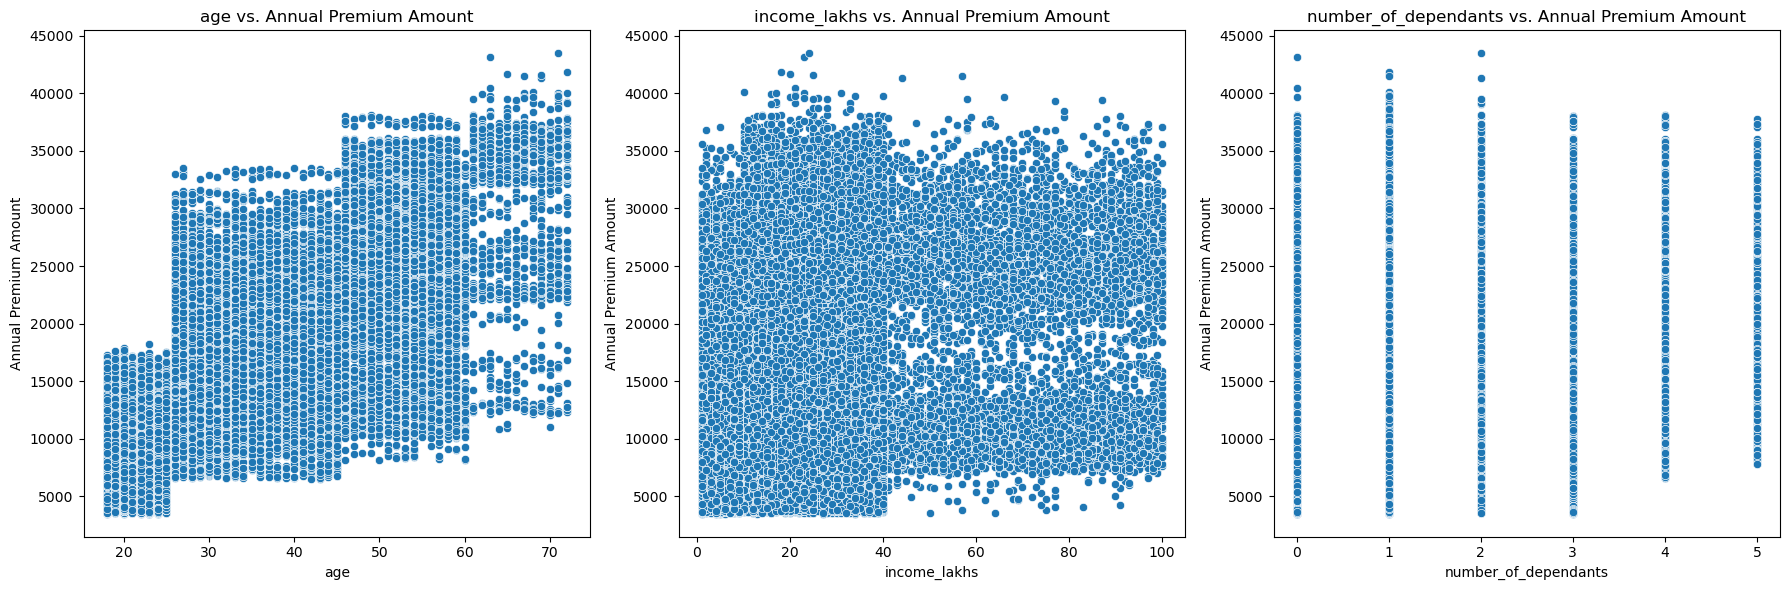

In [160]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6)) 

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout() 
plt.show()

#### 2.Categorical column

In [161]:
Categorical_columns = df2.select_dtypes(["object"]).columns
Categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [162]:
for col in Categorical_columns:
    print(col, ":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer' nan]
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


In [163]:
df2['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
}, inplace=True)

df2['smoking_status'].unique()

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_22860\263445883.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['smoking_status'].replace({
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_22860\263445883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['smoking_status'].replace({


array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [164]:
df2["smoking_status"].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

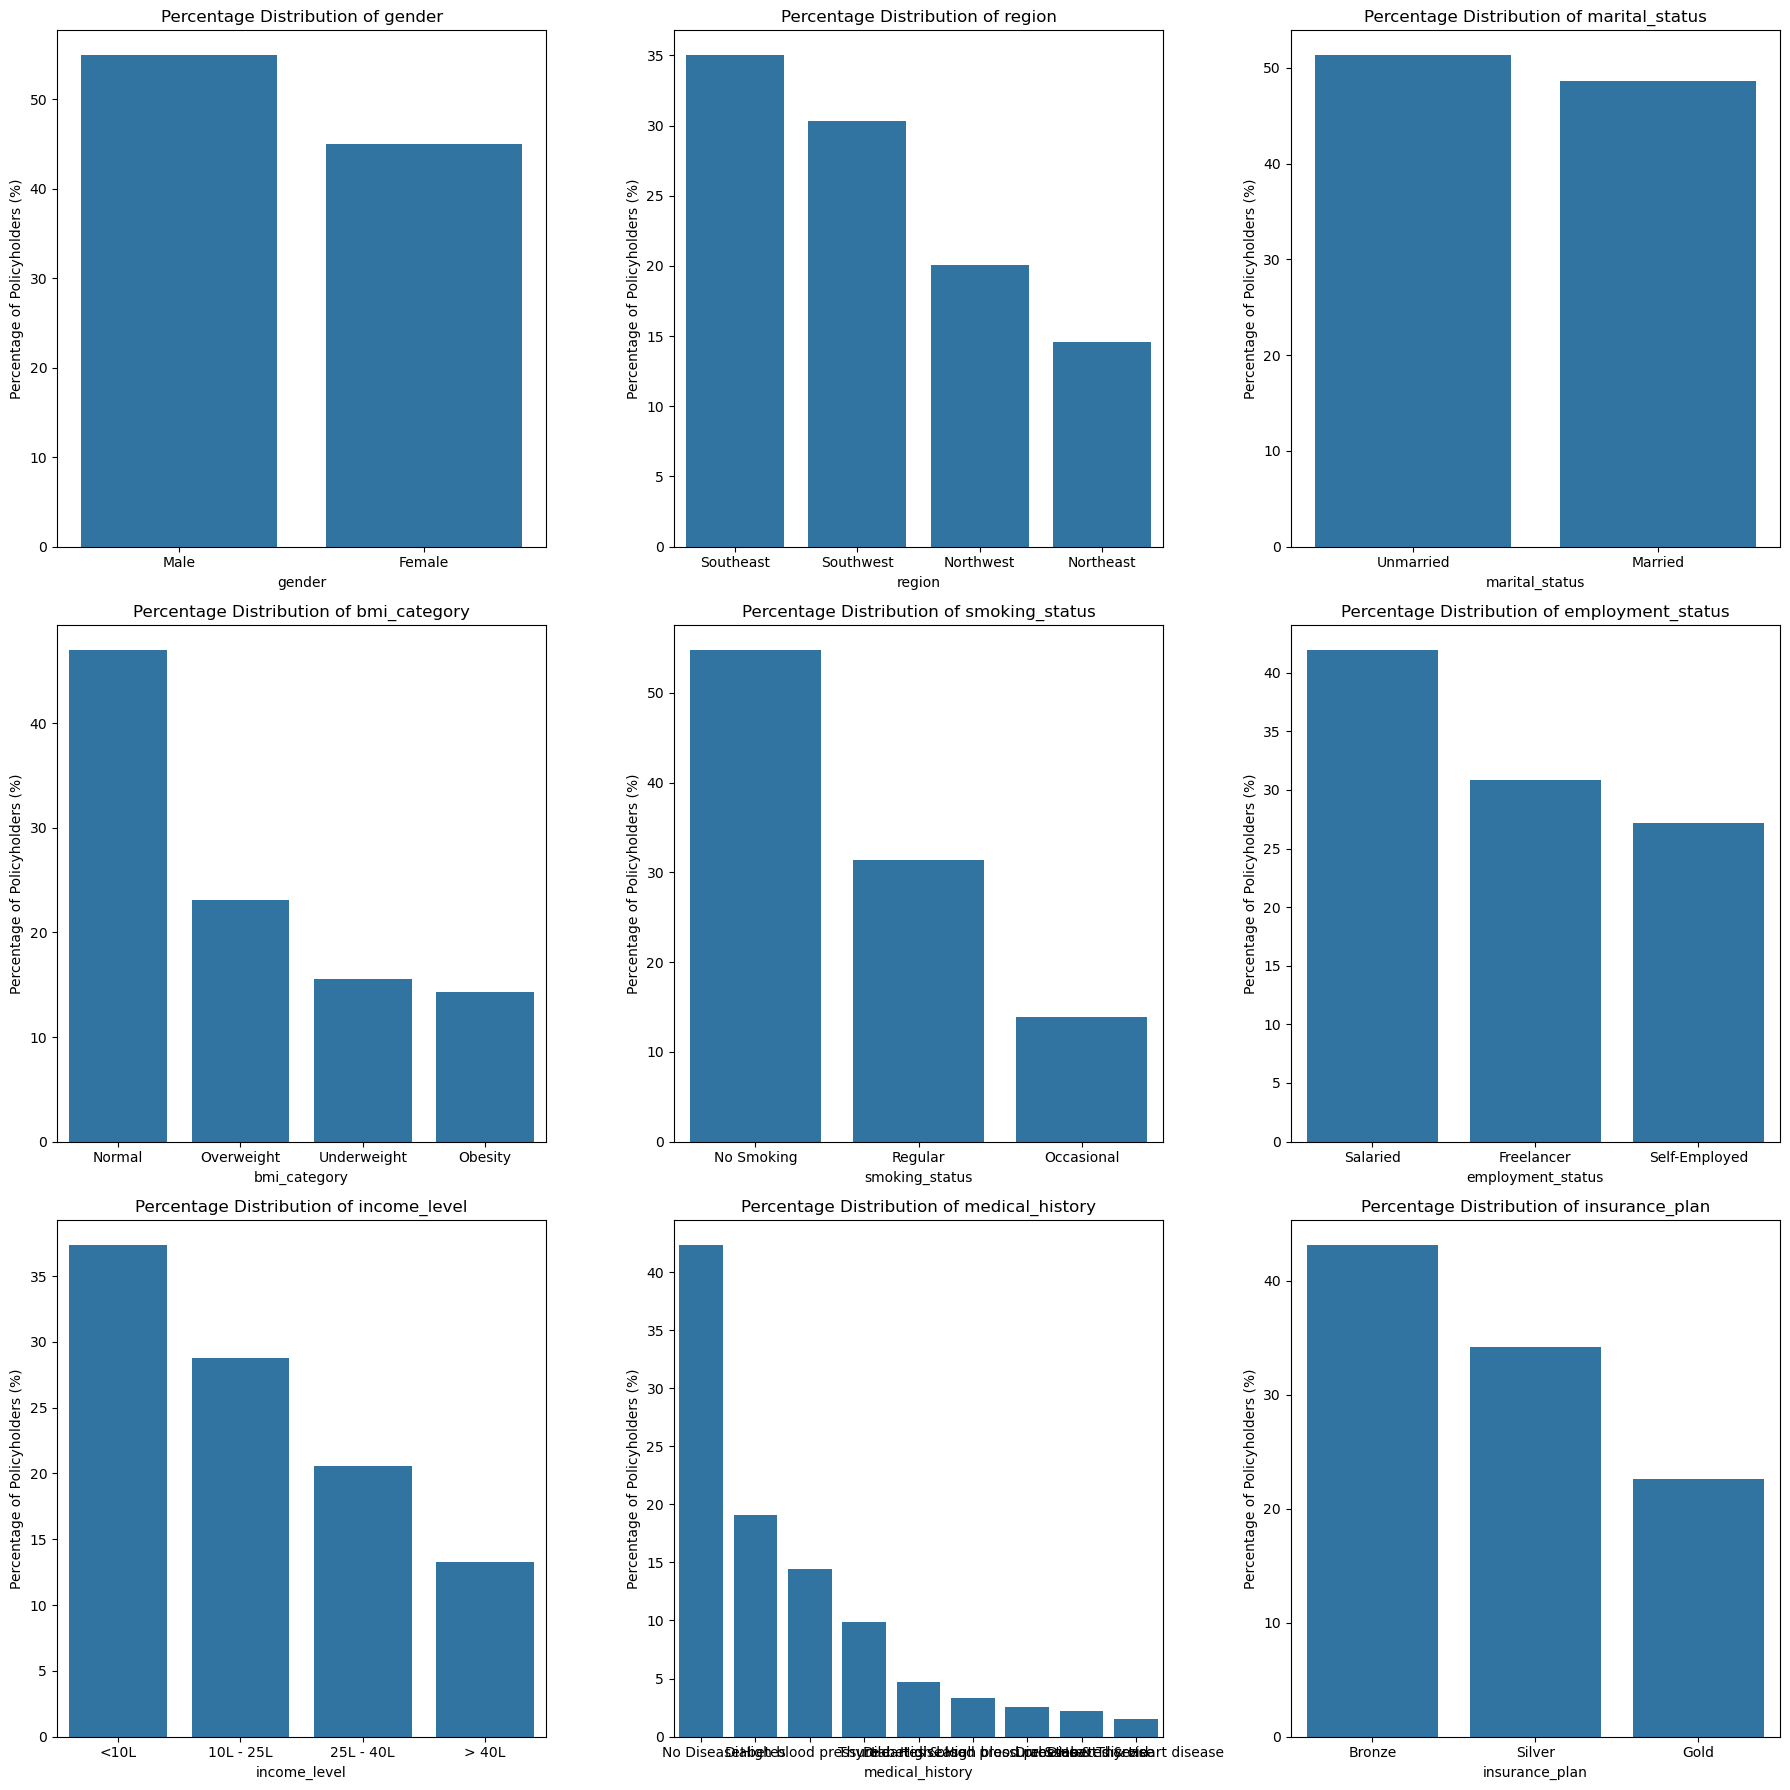

In [165]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  
axes = axes.flatten()  

for ax, column in zip(axes, Categorical_columns):
    # Calculate the percentage distribution of each category
    category_counts = df2[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         5308  3880    5183
25L - 40L         3683  2845    3750
<10L             12229   931    5498
> 40L              329  3654    2642


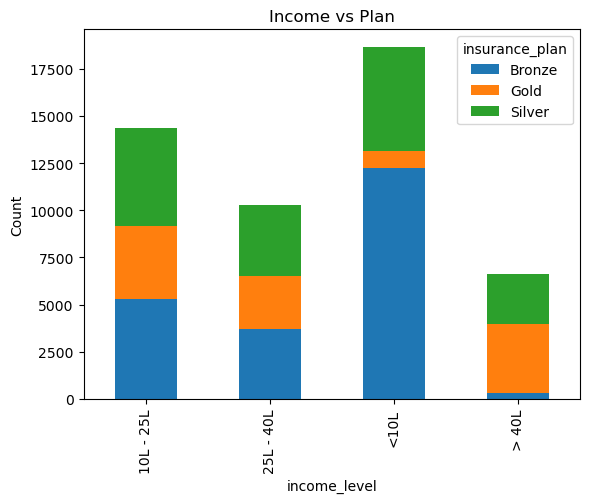

In [166]:
crosstab = pd.crosstab(df2['income_level'], df2['insurance_plan'])
print(crosstab)

crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

Most of the people which less than 10 lakh income have bronze tier of insurance plan

<h2 align="center" style="color:blue">Feature Engineering</h2>

In [167]:
df2.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164


In [168]:
df2["medical_history"].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

##### Assigning some score to each disease based on domain understanding

In [169]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

In [170]:
df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2['disease1'].fillna('none', inplace=True)
df2['disease2'].fillna('none', inplace=True)

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_22860\2811996713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_22860\2811996713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['disease1', 'disease2']] = df2['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_2286

In [171]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none


### calculating risk scores

In [172]:
df2['total_risk_score'] = 0
for disease in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)

max_score = df2['total_risk_score'].max()
min_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_score) / (max_score - min_score)
df2.head(2)

C:\Users\Sarthak\AppData\Local\Temp\ipykernel_22860\3931687836.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['total_risk_score'] = 0
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_22860\3931687836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['total_risk_score'] += df2[disease].map(risk_scores)
C:\Users\Sarthak\AppData\Local\Temp\ipykernel_22860\3931687836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571


In [173]:
df3 = df2.drop(["medical_history", "disease1", "disease2", "total_risk_score"], axis=1)
df3.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Bronze,9053,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Bronze,16339,0.428571


#### Label Encoding for ordinal columns

In [174]:
df3['insurance_plan'] = df3['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [175]:
df3["income_level"].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [176]:
df3['income_level'] = df3['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})
df3.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score
21273,31,Male,Southeast,Unmarried,0,Normal,Regular,Salaried,2,25,2,18244,0.428571
8900,60,Male,Northwest,Married,3,Underweight,Occasional,Self-Employed,2,16,3,30187,0.857143
25410,21,Female,Southeast,Unmarried,0,Normal,Regular,Freelancer,2,13,1,7660,0.000000
7322,44,Male,Southeast,Married,3,Underweight,Regular,Salaried,1,8,1,12875,0.428571
15754,23,Male,Southeast,Married,3,Normal,No Smoking,Freelancer,1,7,1,5626,0.357143


In [177]:
cat_columns2 = df3.select_dtypes(["object"]).columns
cat_columns2

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status'],
      dtype='object')

In [178]:
for col in cat_columns2:
    print(f"{col} : {df3[col].unique()}")

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer' nan]


#### one hot encoding for nominal columns

In [179]:
df4 = pd.get_dummies(df3, columns=cat_columns2, drop_first=True, dtype=int)
df4.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1


In [181]:
df4.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [182]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49932 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              49932 non-null  int64  
 1   number_of_dependants             49932 non-null  int64  
 2   income_level                     49932 non-null  int64  
 3   income_lakhs                     49932 non-null  int64  
 4   insurance_plan                   49932 non-null  int64  
 5   annual_premium_amount            49932 non-null  int64  
 6   normalized_risk_score            49932 non-null  float64
 7   gender_Male                      49932 non-null  int64  
 8   region_Northwest                 49932 non-null  int64  
 9   region_Southeast                 49932 non-null  int64  
 10  region_Southwest                 49932 non-null  int64  
 11  marital_status_Unmarried         49932 non-null  int64  
 12  bmi_category_Obesity   

### Calculating VIF to measure multicollinearity

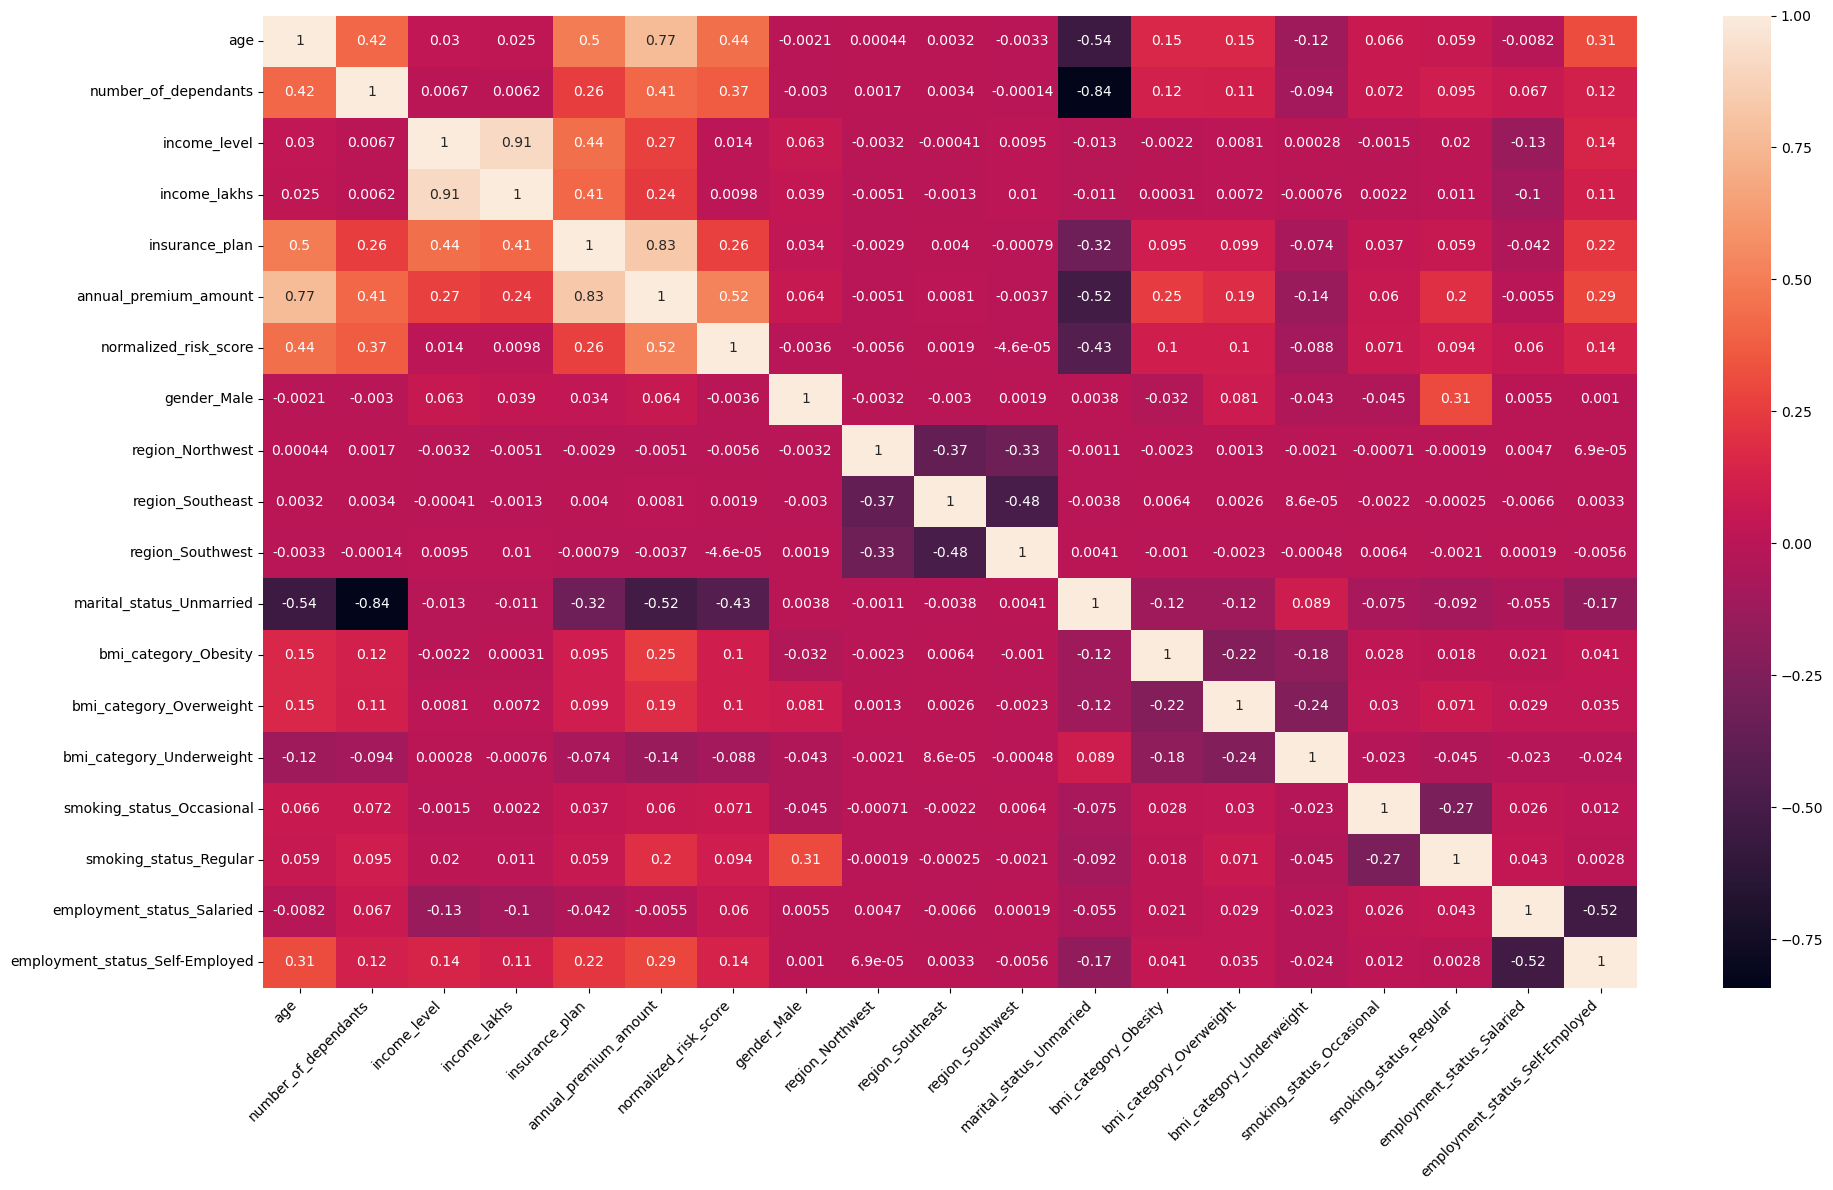

In [185]:
cm = df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### scaling columns using min max scalar

In [187]:
df4.sample(6)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
32458,24,3,4,69,2,7494,0.000000,0,1,0,0,0,0,0,0,1,0,0,1
161,24,0,4,92,2,14306,0.785714,1,1,0,0,1,0,0,0,0,1,0,0
20010,31,3,1,6,1,8795,0.000000,0,0,1,0,0,0,1,0,0,0,1,0
26960,25,0,1,8,1,4640,0.000000,0,1,0,0,1,0,0,1,0,0,1,0
23809,45,1,2,15,2,20224,0.428571,1,0,1,0,1,0,1,0,0,1,0,1
42529,35,3,1,4,1,13754,1.000000,0,0,1,0,0,0,0,0,1,0,1,0


In [188]:
X = df4.drop('annual_premium_amount', axis='columns')
y = df4['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.00000
mean,0.303766,0.343575,0.365844,0.221081,0.397471,0.291860,0.549607,0.200853,0.350336,0.303132,0.513478,0.143175,0.231194,0.155391,0.138288,0.313767,0.419390,0.27205
std,0.253377,0.298418,0.349720,0.223928,0.392440,0.287434,0.497538,0.400642,0.477080,0.459616,0.499823,0.350254,0.421601,0.362281,0.345206,0.464027,0.493464,0.44502
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.074074,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,0.240741,0.400000,0.333333,0.161616,0.500000,0.357143,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,0.500000,0.600000,0.666667,0.303030,0.500000,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [189]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [190]:
calculate_vif(X)

,Column,VIF
0,age,4.567396
1,number_of_dependants,4.534449
2,income_level,12.448718
3,income_lakhs,11.183567
4,insurance_plan,3.585434
5,normalized_risk_score,2.688266
6,gender_Male,2.421203
7,region_Northwest,2.101963
8,region_Southeast,2.921646
9,region_Southwest,2.670860


##### dropping columns one by one

In [191]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,4.545624
1,number_of_dependants,4.526438
2,income_lakhs,2.480280
3,insurance_plan,3.446443
4,normalized_risk_score,2.687974
5,gender_Male,2.409697
6,region_Northwest,2.100194
7,region_Southeast,2.919027
8,region_Southwest,2.668506
9,marital_status_Unmarried,3.392790


In [192]:
X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:blue">Model Training</h2>

#### Attempt 1:
using linear regression, ridge regression, xgboost

### Linear Regression

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (34952, 17)
x test:  (14980, 17)
y train:  (34952,)
y test:  (14980,)


In [194]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.9283466030969239, 0.9277894716815227)

In [233]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr, "R2_score: ", r2_lr)

Linear Regression ==> MSE:  5088820.829402335 RMSE:  2255.841490309622 R2_score:  0.9277894716815227


In [198]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([11308.807638,  -490.258286,  -400.371476, 12518.598126,
        4783.138372,   141.962038,   -41.56741 ,    40.267609,
          -2.210362,  -810.69113 ,  3374.060824,  1643.136677,
         368.915117,   705.116118,  2227.831729,   168.303994,
         376.772009])

In [200]:
feature_importance = model_lr.coef_

coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])
coef_df

,Coefficients
age,11308.807638
number_of_dependants,-490.258286
income_lakhs,-400.371476
insurance_plan,12518.598126
normalized_risk_score,4783.138372
gender_Male,141.962038
region_Northwest,-41.567410
region_Southeast,40.267609
region_Southwest,-2.210362
marital_status_Unmarried,-810.691130


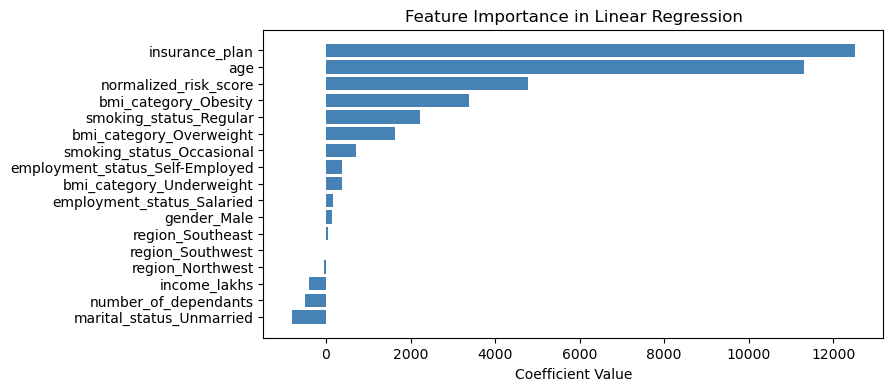

In [201]:
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)


plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

### Ridge Regression 

In [202]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.928346565020256, 0.927790878773953)

In [235]:
y_pred = model_rg.predict(X_test)

mse_rl = mean_squared_error(y_test, y_pred)
r2_rl = r2_score(y_test, y_pred)
rmse_rl = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_rl, "RMSE: ", rmse_rl, "r2_score: ", r2_rl)

Ridge Regression ==> MSE:  5088721.66877528 RMSE:  2255.819511568973 r2_score:  0.927790878773953


### XG Boost

In [219]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9783331155776978

In [220]:
y_pred = model_xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_xgb, "RMSE: ", rmse_xgb)

XGBoost Regression ==> MSE:  1526907.5 RMSE:  1235.6809863391118


### Attempt 2:
using randomizedcv
using xgboost

In [221]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_search.best_score_

y_pred = random_search.predict(X_test)

mse_xgb_rcv = mean_squared_error(y_test, y_pred)
rmse_xgb_rcv = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  1526907.5 RMSE:  1235.6809863391118


In [207]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [209]:
best_model = random_search.best_estimator_

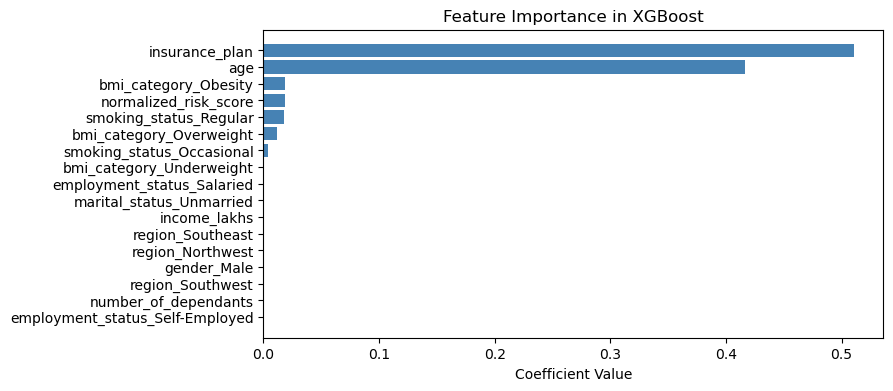

In [210]:
feature_importance = best_model.feature_importances_

coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

### Attempt 3:
1. using XG boost
2. using cross validation
3. Parameter tuning using optuna
4. Using early stopping for computational resources

In [217]:
import optuna


class EarlyStoppingCallback:
    def __init__(self, patience=4, min_trials=10):
        self.patience = patience      
        self.min_trials = min_trials  

    def __call__(self, study, trial):
        if trial.number + 1 < self.min_trials:
            return
        trials_since_best = trial.number - study.best_trial.number
        if trials_since_best >= self.patience:
            print(f"Early stopping at trial {trial.number}: no improvement in "
                  f"{self.patience} trials after best trial {study.best_trial.number}.")
            study.stop()

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "random_state": 42,
    }
    model = XGBRegressor(**params, max_iter=10000)
    scores = cross_val_score(model, X_train, y_train, cv=3,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -scores.mean()  

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(
    objective,
    n_trials=50,                                             
    callbacks=[EarlyStoppingCallback(patience=4, min_trials=10)],
)

# ---- Best result ----
print("Best trial number:", study_xgb.best_trial.number)
print("Best CV RMSE:", study_xgb.best_value)
print("Best params:", study_xgb.best_params)

best_model_XGR = XGBRegressor(**study_xgb.best_params, max_iter=10000)
best_model_XGR.fit(X_train, y_train)

y_pred = best_model_XGR.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

[I 2026-10-04 22:47:07,550] A new study created in memory with name: no-name-930b6689-ee0a-4078-9fcf-d480fe10dfea
[I 2026-10-04 22:47:25,581] Trial 0 finished with value: 1219.3921712239583 and parameters: {'n_estimators': 1331, 'learning_rate': 0.06389435924297755, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.9100502851272313, 'colsample_bytree': 0.6670549395082919, 'reg_lambda': 0.03948537455300249}. Best is trial 0 with value: 1219.3921712239583.
[I 2026-10-04 22:47:33,472] Trial 1 finished with value: 1305.7164306640625 and parameters: {'n_estimators': 788, 'learning_rate': 0.28144834746531894, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.8371006467790065, 'colsample_bytree': 0.6921945302274584, 'reg_lambda': 6.043428047114253}. Best is trial 0 with value: 1219.3921712239583.
[I 2026-10-04 22:47:39,505] Trial 2 finished with value: 1158.0325113932292 and parameters: {'n_estimators': 447, 'learning_rate': 0.06283845963026456, 'max_depth': 5, 'min_child_weight': 12,

Early stopping at trial 9: no improvement in 4 trials after best trial 4.
Best trial number: 4
Best CV RMSE: 1148.493896484375
Best params: {'n_estimators': 857, 'learning_rate': 0.10053583642548235, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.9613763753749386, 'colsample_bytree': 0.809617466847885, 'reg_lambda': 0.03656019807351176}
Test RMSE: 1120.7443397135673
Test MAE: 755.1563720703125
Test R2: 0.9821763634681702


98% R2 score doesn't mean our model is performing really good

### Error analysis

In [227]:
y_pred = best_model_XGR.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test, 
    'predicted': y_pred, 
    'diff': residuals, 
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
7167,28672,28552.505859,-119.494141,-0.416762
14503,13400,12970.092773,-429.907227,-3.208263
43991,8892,6626.999512,-2265.000488,-25.472340
47910,29595,30137.406250,542.406250,1.832763
12861,18734,18638.703125,-95.296875,-0.508684


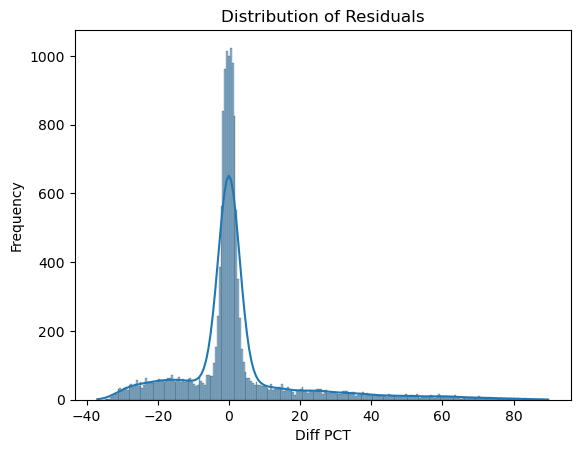

In [228]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [229]:
X_test.shape

(14980, 17)

In [230]:
extreme_error_threshold = 10
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
43991,8892,6626.999512,-2265.000488,-25.472340
33892,8642,7304.820801,-1337.179199,-15.473029
32115,8643,6960.178711,-1682.821289,-19.470338
41992,5260,6304.756348,1044.756348,19.862288
9393,9299,7009.265137,-2289.734863,-24.623453


In [231]:
extreme_results_df.shape

(4312, 4)

In [232]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

28.785046728971963

29% extreme error mean the 29% customers were either overcharge or undercharged by 10%.

In [236]:
extreme_results_df[abs(extreme_results_df.diff_pct)>50].sort_values("diff_pct",ascending=False)

,actual,predicted,diff,diff_pct
22589,3682,6986.705078,3304.705078,89.752990
37192,3541,6670.852051,3129.852051,88.388931
47573,3531,6639.273438,3108.273438,88.028135
34054,3560,6678.372070,3118.372070,87.594721
31297,3569,6645.624023,3076.624023,86.204091
...,...,...,...,...
27900,4739,7117.603027,2378.603027,50.192088
36594,4493,6746.034668,2253.034668,50.145441
16904,5011,7523.172852,2512.172852,50.133164
13736,4371,6562.249023,2191.249023,50.131527


472 customers were overcharged or undercharged by more than 50%.

In [240]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head(2)

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
43991,0.129630,0.6,0.070707,0.0,0.0,0,0,1,0,0,0,0,1,0,0,1,0
33892,0.111111,0.4,0.303030,0.0,0.0,1,1,0,0,1,0,1,0,0,1,1,0


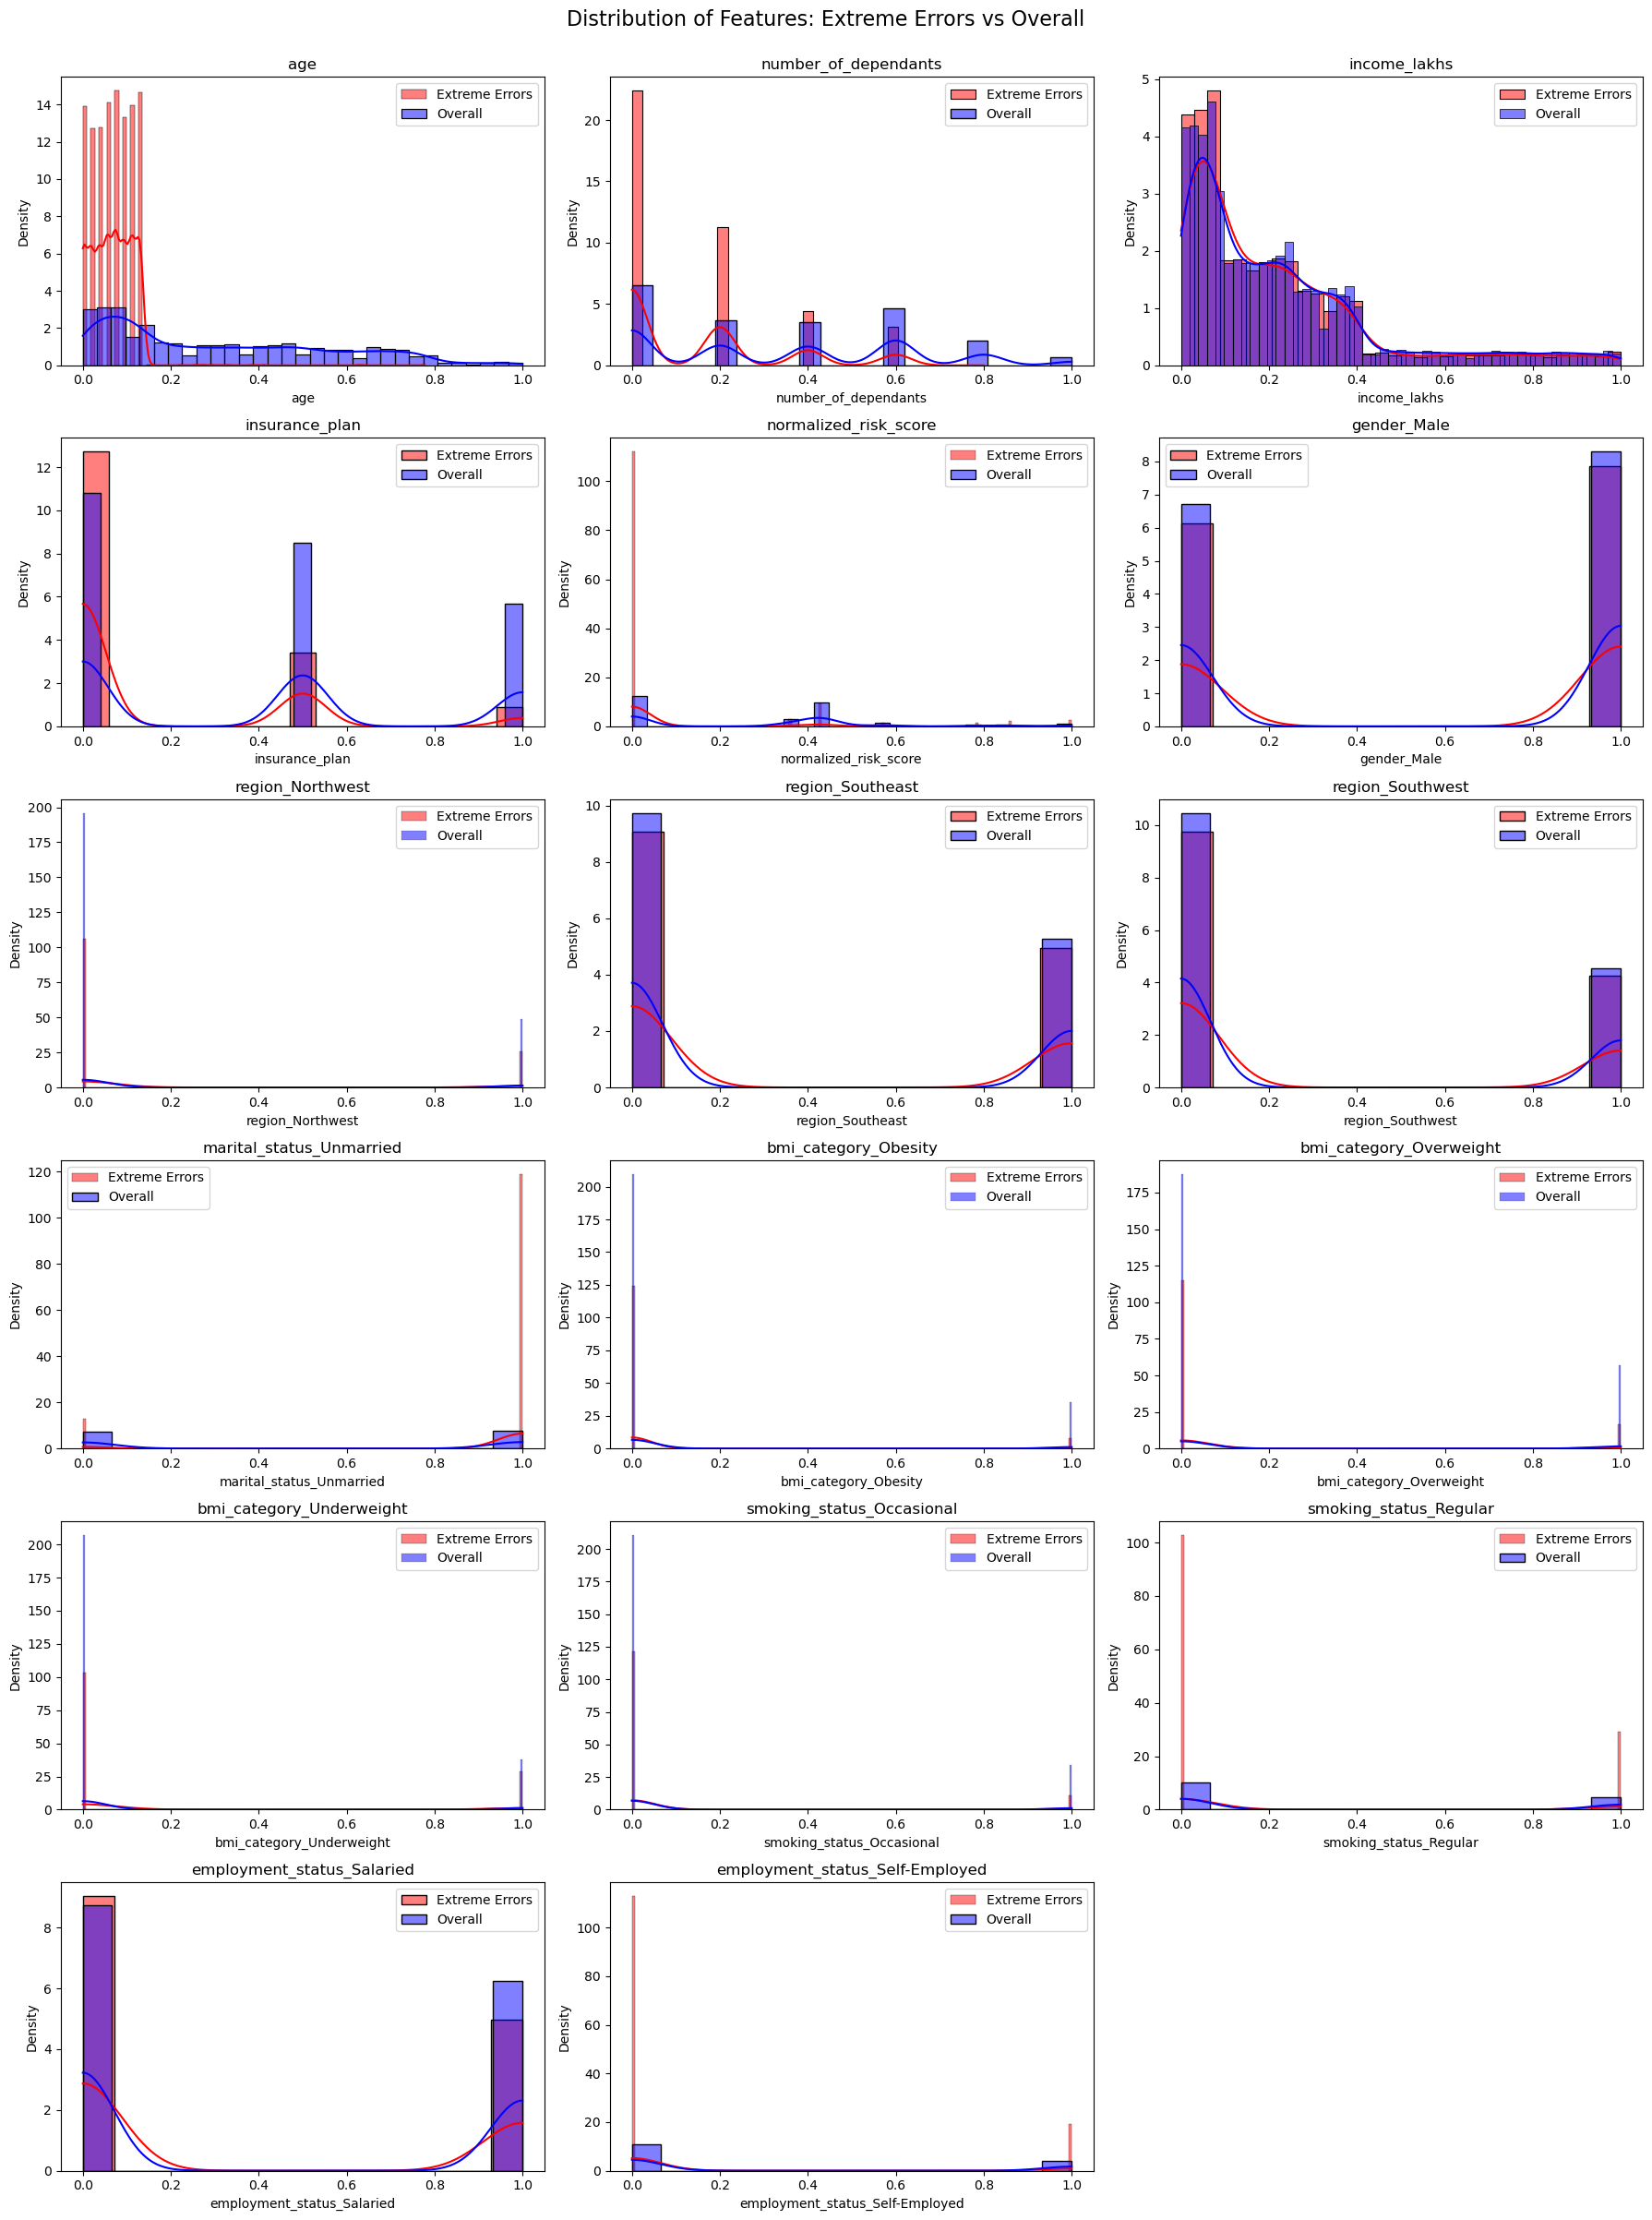

In [241]:
import math
features = X_test.columns
n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(extreme_errors_df[feature], color='red', label='Extreme Errors',
                 kde=True, stat='density', common_norm=False, ax=ax)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5,
                 kde=True, stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{feature}')
    ax.legend()

for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle('Distribution of Features: Extreme Errors vs Overall', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

The distribution of extreme error df and age is not same, so there we need to solve the issue

### Reverse Scaling

In [243]:
extreme_errors_df['income_level']=-1

In [244]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_errors_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,25.0,3.0,-2.0,8.0,1.0
1,24.0,2.0,-2.0,31.0,1.0
2,24.0,2.0,-2.0,23.0,1.0
3,21.0,1.0,-2.0,23.0,1.0
4,18.0,3.0,-2.0,32.0,1.0


In [245]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,4312.000000,4312.000000,4312.0,4312.000000,4312.000000
mean,21.610853,0.717301,-2.0,21.420686,1.304035
std,2.525261,0.936191,0.0,21.127996,0.561341
min,18.000000,0.000000,-2.0,1.000000,1.000000
25%,20.000000,0.000000,-2.0,6.000000,1.000000
50%,22.000000,0.000000,-2.0,15.000000,1.000000
75%,24.000000,1.000000,-2.0,30.000000,2.000000
max,60.000000,4.000000,-2.0,100.000000,3.000000


In [254]:
df_reversed["age"].quantile(0.99)

np.float64(25.0)

<Axes: xlabel='age', ylabel='Count'>

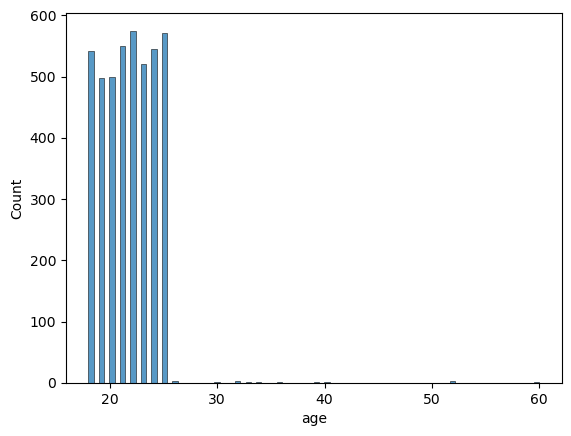

In [255]:
sns.histplot(df_reversed.age)

Majority of extreme error from young age